In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
# 1. Factory Coordinates DataFrame
factories_df = pd.DataFrame([
    {"Factory": "Lot's O' Nuts", "Factory_Lat": 32.881893, "Factory_Lon": -111.768036},
    {"Factory": "Wicked Choccy's", "Factory_Lat": 32.076176, "Factory_Lon": -81.088371},
    {"Factory": "Sugar Shack", "Factory_Lat": 48.119140, "Factory_Lon": -96.181150},
    {"Factory": "Secret Factory", "Factory_Lat": 41.446333, "Factory_Lon": -90.565487},
    {"Factory": "The Other Factory", "Factory_Lat": 35.117500, "Factory_Lon": -89.971107}
])

# 2. Products to Factory Mapping DataFrame
product_mapping_df = pd.DataFrame([
    {"Division": "Chocolate", "Product Name": "Wonka Bar - Nutty Crunch Surprise", "Factory": "Lot's O' Nuts"},
    {"Division": "Chocolate", "Product Name": "Wonka Bar - Fudge Mallows", "Factory": "Lot's O' Nuts"},
    {"Division": "Chocolate", "Product Name": "Wonka Bar -Scrumdiddlyumptious", "Factory": "Lot's O' Nuts"},
    {"Division": "Chocolate", "Product Name": "Wonka Bar - Milk Chocolate", "Factory": "Wicked Choccy's"},
    {"Division": "Chocolate", "Product Name": "Wonka Bar - Triple Dazzle Caramel", "Factory": "Wicked Choccy's"},
    {"Division": "Sugar", "Product Name": "Laffy Taffy", "Factory": "Sugar Shack"},
    {"Division": "Sugar", "Product Name": "SweeTARTS", "Factory": "Sugar Shack"},
    {"Division": "Sugar", "Product Name": "Nerds", "Factory": "Sugar Shack"},
    {"Division": "Sugar", "Product Name": "Fun Dip", "Factory": "Sugar Shack"},
    {"Division": "Other", "Product Name": "Fizzy Lifting Drinks", "Factory": "Sugar Shack"},
    {"Division": "Sugar", "Product Name": "Everlasting Gobstopper", "Factory": "Secret Factory"},
    {"Division": "Sugar", "Product Name": "Hair Toffee", "Factory": "The Other Factory"},
    {"Division": "Other", "Product Name": "Lickable Wallpaper", "Factory": "Secret Factory"},
    {"Division": "Other", "Product Name": "Wonka Gum", "Factory": "Secret Factory"},
    {"Division": "Other", "Product Name": "Kazookles", "Factory": "The Other Factory"}
])

# Merge mappings into a single lookup table
factory_lookup = pd.merge(product_mapping_df, factories_df, on="Factory", how="left")
factory_lookup.head()

,Division,Product Name,Factory,Factory_Lat,Factory_Lon
0,Chocolate,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,32.881893,-111.768036
1,Chocolate,Wonka Bar - Fudge Mallows,Lot's O' Nuts,32.881893,-111.768036
2,Chocolate,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,32.881893,-111.768036
3,Chocolate,Wonka Bar - Milk Chocolate,Wicked Choccy's,32.076176,-81.088371
4,Chocolate,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,32.076176,-81.088371


In [4]:
# Load dataset
df = pd.read_excel(r"C:\Users\Admin\Desktop\UM PROJECTS\Nassau_Candy_Distributor.csv.xlsx")  # or pd.read_excel('nassau_candy_dataset.xlsx')

# Parse dates to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Calculate Shipping Lead Time in days
df['Shipping Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

# Data Validation: Filter out negative or unrealistic lead times
df_clean = df[df['Shipping Lead Time'] >= 0].copy()

# Merge Factory and Location information based on Product Name
df_clean = pd.merge(
    df_clean, 
    factory_lookup[['Product Name', 'Factory', 'Factory_Lat', 'Factory_Lon']], 
    on='Product Name', 
    how='left'
)

# Define Route representation (Factory -> Customer State)
df_clean['Route'] = df_clean['Factory'] + " → " + df_clean['State/Province']

print(f"Cleaned dataset shape: {df_clean.shape}")
df_clean.head()

Cleaned dataset shape: (10194, 23)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Lead Time,Factory,Factory_Lat,Factory_Lon,Route
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,909,Wicked Choccy's,32.076176,-81.088371,Wicked Choccy's → Texas
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60,909,Wicked Choccy's,32.076176,-81.088371,Wicked Choccy's → Illinois
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00,909,Lot's O' Nuts,32.881893,-111.768036,Lot's O' Nuts → Illinois
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30,909,Lot's O' Nuts,32.881893,-111.768036,Lot's O' Nuts → Illinois
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,912,Wicked Choccy's,32.076176,-81.088371,Wicked Choccy's → Pennsylvania


In [5]:
# Threshold for delayed shipment (e.g., lead time > 4 days)
DELAY_THRESHOLD = 4

# Flag delayed shipments
df_clean['Is_Delayed'] = df_clean['Shipping Lead Time'] > DELAY_THRESHOLD

# Route-level aggregations
route_kpis = df_clean.groupby('Route').agg(
    Factory=('Factory', 'first'),
    Customer_State=('State/Province', 'first'),
    Customer_Region=('Region', 'first'),
    Total_Shipments=('Order ID', 'count'),
    Avg_Lead_Time=('Shipping Lead Time', 'mean'),
    Lead_Time_Std=('Shipping Lead Time', 'std'),
    Delayed_Shipments=('Is_Delayed', 'sum'),
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Gross Profit', 'sum')
).reset_index()

# Calculate Delay Frequency (%)
route_kpis['Delay_Frequency_%'] = (route_kpis['Delayed_Shipments'] / route_kpis['Total_Shipments']) * 100

# Min-Max Normalization for Route Efficiency Score (0 = Worst, 100 = Best)
min_lt = route_kpis['Avg_Lead_Time'].min()
max_lt = route_kpis['Avg_Lead_Time'].max()

route_kpis['Efficiency_Score'] = 100 * (1 - (route_kpis['Avg_Lead_Time'] - min_lt) / (max_lt - min_lt))

# Display top performing routes
route_kpis.sort_values(by='Efficiency_Score', ascending=False).head(10)

,Route,Factory,Customer_State,Customer_Region,Total_Shipments,Avg_Lead_Time,Lead_Time_Std,Delayed_Shipments,Total_Sales,Total_Profit,Delay_Frequency_%,Efficiency_Score
76,Secret Factory → Nebraska,Secret Factory,Nebraska,Interior,1,906.0,NaN,1,2.50,1.30,100.0,100.000000
80,Secret Factory → New Mexico,Secret Factory,New Mexico,Pacific,2,906.0,2.828427,2,12.50,6.50,100.0,100.000000
121,The Other Factory → Louisiana,The Other Factory,Louisiana,Gulf,1,907.0,NaN,1,9.75,0.75,100.0,99.864130
115,The Other Factory → Connecticut,The Other Factory,Connecticut,Atlantic,2,907.5,2.121320,2,9.75,0.75,100.0,99.796196
158,Wicked Choccy's → Maine,Wicked Choccy's,Maine,Atlantic,2,908.0,0.000000,2,55.25,36.07,100.0,99.728261
75,Secret Factory → Mississippi,Secret Factory,Mississippi,Gulf,1,908.0,NaN,1,80.00,40.00,100.0,99.728261
70,Secret Factory → Louisiana,Secret Factory,Louisiana,Gulf,2,908.5,0.707107,2,11.25,5.85,100.0,99.660326
74,Secret Factory → Minnesota,Secret Factory,Minnesota,Interior,1,909.0,NaN,1,5.00,2.60,100.0,99.592391
64,Secret Factory → Delaware,Secret Factory,Delaware,Atlantic,1,909.0,NaN,1,60.00,30.00,100.0,99.592391
88,Secret Factory → South Carolina,Secret Factory,South Carolina,Gulf,1,909.0,NaN,1,6.25,3.25,100.0,99.592391


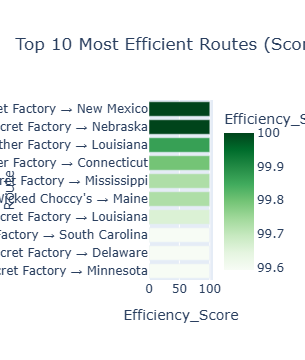

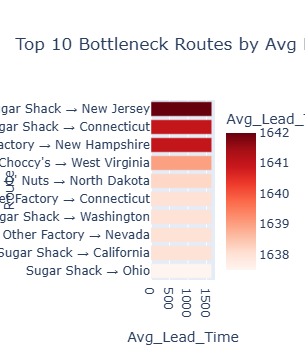

In [6]:
# Top 10 Most Efficient Routes
fig_top10 = px.bar(
    route_kpis.sort_values(by='Efficiency_Score', ascending=False).head(10),
    x='Efficiency_Score',
    y='Route',
    orientation='h',
    title='Top 10 Most Efficient Routes (Score 0-100)',
    color='Efficiency_Score',
    color_continuous_scale='Greens'
)
fig_top10.update_layout(yaxis={'categoryorder': 'total ascending'})
fig_top10.show()

# Top 10 Bottleneck / Slowest Routes
fig_bottom10 = px.bar(
    route_kpis.sort_values(by='Avg_Lead_Time', ascending=False).head(10),
    x='Avg_Lead_Time',
    y='Route',
    orientation='h',
    title='Top 10 Bottleneck Routes by Avg Lead Time (Days)',
    color='Avg_Lead_Time',
    color_continuous_scale='Reds'
)
fig_bottom10.update_layout(yaxis={'categoryorder': 'total ascending'})
fig_bottom10.show()

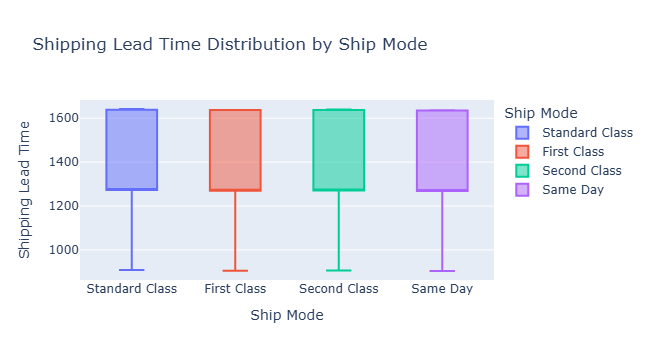

In [7]:
mode_summary = df_clean.groupby('Ship Mode').agg(
    Avg_Lead_Time=('Shipping Lead Time', 'mean'),
    Total_Orders=('Order ID', 'count'),
    Avg_Sales=('Sales', 'mean'),
    Avg_Profit=('Gross Profit', 'mean')
).reset_index()

fig_mode = px.box(
    df_clean, 
    x='Ship Mode', 
    y='Shipping Lead Time', 
    color='Ship Mode',
    title='Shipping Lead Time Distribution by Ship Mode'
)
fig_mode.show()

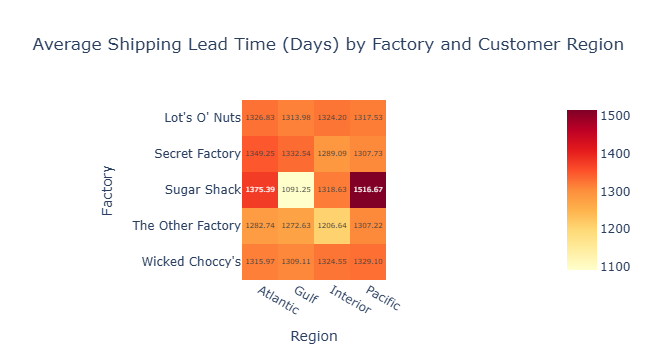

In [8]:
region_matrix = df_clean.pivot_table(
    index='Factory', 
    columns='Region', 
    values='Shipping Lead Time', 
    aggfunc='mean'
)

fig_heatmap = px.imshow(
    region_matrix,
    text_auto=".2f",
    color_continuous_scale='YlOrRd',
    title='Average Shipping Lead Time (Days) by Factory and Customer Region'
)
fig_heatmap.show()

In [9]:
# Save clean order-level data and route KPI summaries
df_clean.to_csv('processed_candy_shipping_data.csv', index=False)
route_kpis.to_csv('route_kpi_summary.csv', index=False)
print("Files saved successfully! You can now load these directly into your Streamlit app.")

Files saved successfully! You can now load these directly into your Streamlit app.
